# Monte Carlo Control with Exploring Starts on Blackjack

**Reproduces S&B Fig 5.2** (§5.3, p.100).

Estimates the optimal action-value function `Q*` and optimal policy `pi*`
using Monte Carlo with Exploring Starts (Generalized Policy Iteration).
Each episode:

1. **Exploring start**: sample `(s_0, a_0)` uniformly at random.
2. **Episode generation**: follow the current greedy policy from step 1 onward.
3. **Policy evaluation**: update `Q(s, a)` via incremental average of returns.
4. **Policy improvement**: `pi(s) <- argmax_a Q(s, a)` (greedy), interleaved with (3).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rl.envs.blackjack import Blackjack
from rl.monte_carlo.mc_control_es import mc_control_es

from blackjack_plots import plot_fig_5_2

## Run MC Control with Exploring Starts

S&B uses 500,000 episodes for Fig 5.2 (p.97: *"after 500,000 games the value
function is very well approximated"*). Takes ~1-3 min on a typical laptop.

In [2]:
env = Blackjack()
rng = np.random.default_rng(seed=0)

n_episodes = 1000000
Q, pi = mc_control_es(env, rng, n_episodes=n_episodes)

V_star = Q.max(axis=1)
print(f'Q  -> shape={Q.shape},  range=[{Q.min():+.3f}, {Q.max():+.3f}]')
print(f'pi -> shape={pi.shape}, STICK fraction = {(pi[:200] == env.STICK).mean():.1%}')
print(f'V* -> range=[{V_star[:200].min():+.3f}, {V_star[:200].max():+.3f}]')

Q  -> shape=(201, 2),  range=[-1.000, +0.942]
pi -> shape=(201,), STICK fraction = 56.0%
V* -> range=[-0.624, +0.942]


## Plot Fig 5.2 (pi\* and V\*)

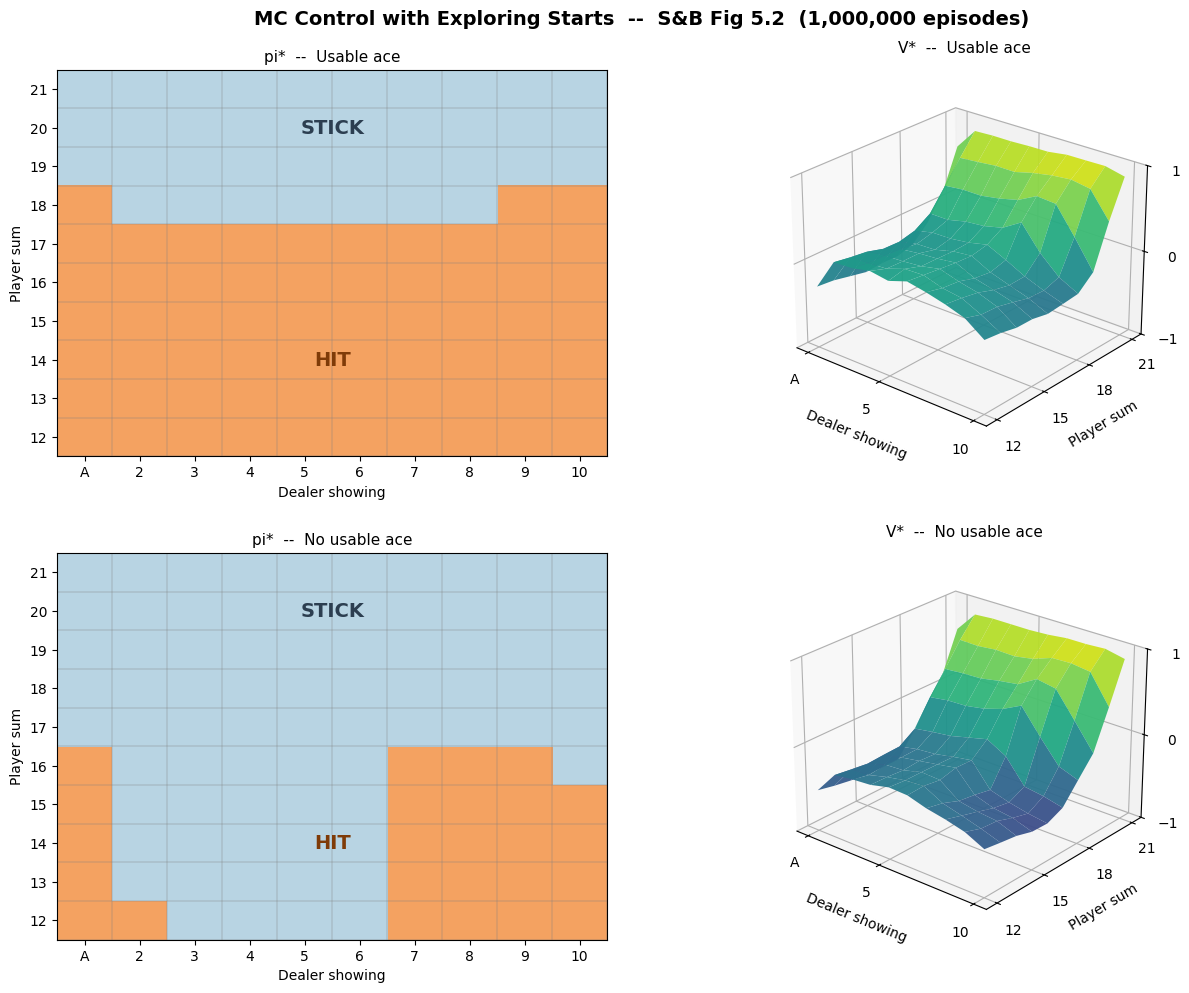

In [3]:
fig = plot_fig_5_2(Q, pi, n_episodes=n_episodes)
plt.show()

## Reading the optimal policy

### Usable ace (top-left panel)

With a usable ace, the player holds a "safety net" — if a hit pushes the sum
above 21, the ace automatically converts from 11 to 1, preventing a bust.
This makes hitting virtually risk-free at moderate sums:

- **HIT on 12–18**: the ace absorbs any bust risk, so the player aggressively
  tries to improve a weak hand.
- **STICK on 19–21**: the hand is already strong enough to win most of the time;
  hitting would risk downgrading the ace (losing the usable property) for
  minimal gain.

The STICK region is small — only the very top of the grid. This is the
signature of the usable-ace advantage.

### No usable ace (bottom-left panel)

Without the ace safety net, every hit risks busting. The policy balances two
competing risks:

- **Against weak dealer cards (2–6)**: the dealer is likely to bust (they must
  hit until 17, and a low showing card often leads to bust). So the player can
  afford to STICK on moderate sums (13–16) and "let the dealer bust."
- **Against strong dealer cards (7–10, Ace)**: the dealer will likely end up
  with 17–21. The player must HIT to improve, even at the risk of busting.
  The STICK threshold is higher (~17).

This creates the characteristic **step** in the policy boundary: STICK
threshold drops from ~17 (vs strong dealer) to ~13 (vs weak dealer).

### V\* surfaces (right column)

- **V\* near +1 at sum 21**: almost certain win regardless of dealer card.
- **V\* decreases as player sum drops**: weaker hands win less often.
- **V\* dips against dealer Ace and 10**: these are the dealer's strongest
  showing cards.
- **Usable-ace V\* is generally higher** than no-usable-ace V\*: the safety
  net genuinely improves expected returns.

## Spot-check: V\* at notable states

In [4]:
checks = [
    (21,  2, True,  'sum=21 vs dealer 2 (usable ace)  — near-certain win'),
    (21, 10, False, 'sum=21 vs dealer 10 (no ace)     — strong but dealer could tie'),
    (12, 10, False, 'sum=12 vs dealer 10 (no ace)     — worst position'),
    (18,  6, True,  'sum=18 vs dealer 6 (usable ace)  — moderate'),
]
print('V* spot-checks:')
for ps, ds, ace, desc in checks:
    s = env._encode(ps, ds, ace)
    action = 'STICK' if pi[s] == env.STICK else 'HIT'
    print(f'  V*({ps:2d}, {ds:2d}, ace={str(ace):5s}) = {V_star[s]:+.3f}  pi*={action:5s}  ({desc})')

V* spot-checks:
  V*(21,  2, ace=True ) = +0.878  pi*=STICK  (sum=21 vs dealer 2 (usable ace)  — near-certain win)
  V*(21, 10, ace=False) = +0.894  pi*=STICK  (sum=21 vs dealer 10 (no ace)     — strong but dealer could tie)
  V*(12, 10, ace=False) = -0.439  pi*=HIT    (sum=12 vs dealer 10 (no ace)     — worst position)
  V*(18,  6, ace=True ) = +0.257  pi*=STICK  (sum=18 vs dealer 6 (usable ace)  — moderate)
